# 03 — Notebook Overfitting
## Kernel SVM volontairement sur-ajusté (high variance)

**Objectif :** construire délibérément un modèle Kernel SVM en situation d'**overfitting**, expliquer pourquoi il l'est, et le comparer au notebook `02_Underfitting.ipynb`. Le meilleur des deux sera repris et optimisé en Phase 5 (`04_Optimisation.ipynb`).

Le prétraitement (échantillon stratifié 12 000 lignes, standardisation, one-hot encoding, split 80/20) est identique à celui du notebook Underfitting — voir `src/preprocessing.py` et la Phase 2 documentée dans `02_Underfitting.ipynb` pour la justification complète. On applique ici exactement le même pipeline afin que la comparaison porte uniquement sur les hyperparamètres du modèle.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from src.data import load_dataset, get_modeling_sample, get_X_y
from src.preprocessing import build_preprocessor, split_data
from src.config import REPORTS_DIR, RANDOM_STATE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
REPORTS_DIR.mkdir(exist_ok=True)

df = load_dataset()
sample = get_modeling_sample(df)
X, y = get_X_y(sample)
X_train, X_test, y_train, y_test = split_data(X, y)

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f"Train: {X_train_t.shape}, Test: {X_test_t.shape}")

Train: (9600, 13), Test: (2400, 13)


## Construction volontaire d'un modèle en overfitting

Cette fois, on pousse les deux mêmes hyperparamètres à l'**extrême opposé** :

- **`C` très élevé** (`C=1000`) : le modèle est quasiment non régularisé — chaque erreur de classification sur le train est très fortement pénalisée, donc l'algorithme va tout faire pour classer correctement **chaque point d'entraînement**, y compris le bruit.
- **`gamma` très élevé** (`gamma=1`) : chaque point n'influence plus qu'une toute petite zone autour de lui → la frontière de décision devient extrêmement sinueuse, capable d'isoler des points individuels. C'est un facteur de **haute variance**.

Avec un `C` et un `gamma` élevés combinés, le modèle a la capacité de **mémoriser** les données d'entraînement plutôt que d'apprendre une règle généralisable.


In [2]:
overfit_model = SVC(kernel="rbf", C=1000, gamma=1, random_state=RANDOM_STATE)
overfit_model.fit(X_train_t, y_train)

y_train_pred = overfit_model.predict(X_train_t)
y_test_pred = overfit_model.predict(X_test_t)

print(f"Nombre de vecteurs de support : {overfit_model.n_support_.sum()} / {len(y_train)} ({overfit_model.n_support_.sum()/len(y_train)*100:.1f}%)")

Nombre de vecteurs de support : 6952 / 9600 (72.4%)


## Métriques

In [3]:
def compute_metrics(y_true, y_pred, label):
    return {
        "set": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

overfit_metrics = pd.DataFrame([
    compute_metrics(y_train, y_train_pred, "train"),
    compute_metrics(y_test, y_test_pred, "test"),
])
overfit_metrics

,set,accuracy,precision,recall,f1
0,train,1.0000,1.000000,1.000000,1.000000
1,test,0.8775,0.136986,0.041494,0.063694


In [4]:
print("=== Classification report — TEST ===")
print(classification_report(y_test, y_test_pred, target_names=["Not Depressed", "Depressed"], zero_division=0))

=== Classification report — TEST ===
               precision    recall  f1-score   support

Not Depressed       0.90      0.97      0.93      2159
    Depressed       0.14      0.04      0.06       241

     accuracy                           0.88      2400
    macro avg       0.52      0.51      0.50      2400
 weighted avg       0.82      0.88      0.85      2400



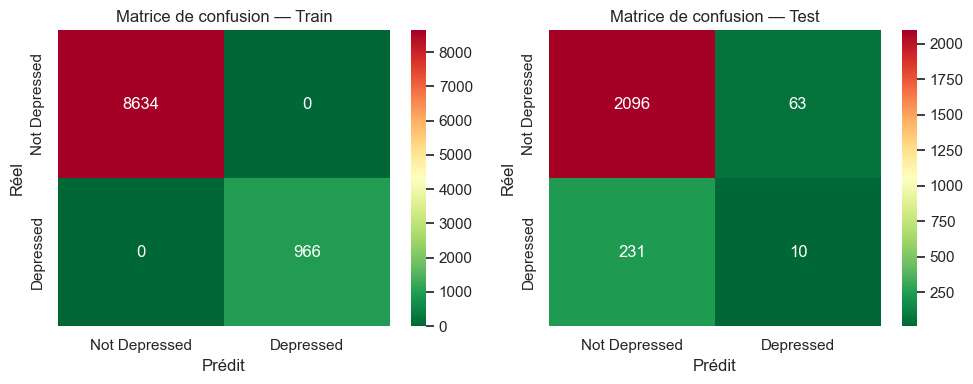

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [(y_train, y_train_pred, "Train"), (y_test, y_test_pred, "Test")],
):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn_r", ax=ax,
                xticklabels=["Not Depressed", "Depressed"],
                yticklabels=["Not Depressed", "Depressed"])
    ax.set_title(f"Matrice de confusion — {title}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "overfit_confusion_matrices.png", bbox_inches="tight")
plt.show()

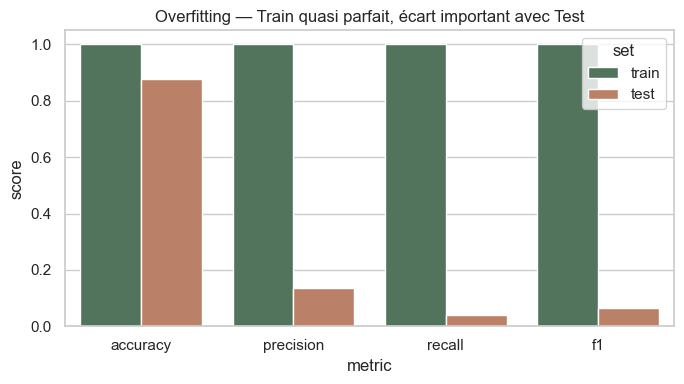

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics_plot = overfit_metrics.melt(id_vars="set", var_name="metric", value_name="score")
sns.barplot(data=metrics_plot, x="metric", y="score", hue="set", ax=ax, palette=["#4C7A5A", "#C97B5A"])
ax.set_ylim(0, 1.05)
ax.set_title("Overfitting — Train quasi parfait, écart important avec Test")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "overfit_train_vs_test.png", bbox_inches="tight")
plt.show()

## Interprétation

Les résultats confirment le diagnostic d'**overfitting** :

- **Accuracy train = 1.000, F1 train = 1.000** : le modèle classe parfaitement chaque exemple du jeu d'entraînement, y compris la classe minoritaire. Avec **72.4 %** des observations d'entraînement devenues vecteurs de support (6952 / 9600), le modèle s'est essentiellement construit autour de chaque point plutôt qu'appris une frontière généralisable.
- **Chute nette sur le test** : accuracy test = 0.877 (inférieure au 0.900 obtenu même par un modèle trivial qui prédirait toujours la classe majoritaire !) et F1 test = 0.064. Le modèle a appris du bruit propre à l'échantillon d'entraînement, qui ne se reproduit pas dans le test.
- **Écart train/test massif** (F1 : 1.000 → 0.064) : c'est la signature caractéristique de l'overfitting (faible biais, haute variance) — à l'opposé du notebook Underfitting où train et test étaient quasi identiques mais tous deux mauvais.

Ce modèle est également **inutilisable en pratique**, pour la raison inverse du précédent : il a trop de capacité et exploite le bruit du train au lieu de la structure réelle des données.


In [7]:
overfit_summary = {
    "model": "SVC(kernel='rbf', C=1000, gamma=1)",
    "n_support_vectors": int(overfit_model.n_support_.sum()),
    "train": compute_metrics(y_train, y_train_pred, "train"),
    "test": compute_metrics(y_test, y_test_pred, "test"),
}
with open(REPORTS_DIR / "overfit_metrics.json", "w") as f:
    json.dump(overfit_summary, f, indent=2, default=float)

print("Sauvegardé : reports/overfit_metrics.json")
overfit_summary

Sauvegardé : reports/overfit_metrics.json


{'model': "SVC(kernel='rbf', C=1000, gamma=1)",
 'n_support_vectors': 6952,
 'train': {'set': 'train',
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0},
 'test': {'set': 'test',
  'accuracy': 0.8775,
  'precision': 0.136986301369863,
  'recall': 0.04149377593360996,
  'f1': 0.06369426751592357}}